 - 1-5,11 FALL  6-10 NONFALL 11(눕기)까지 FALL로 라벨링 후 RandomForest 모델 결과

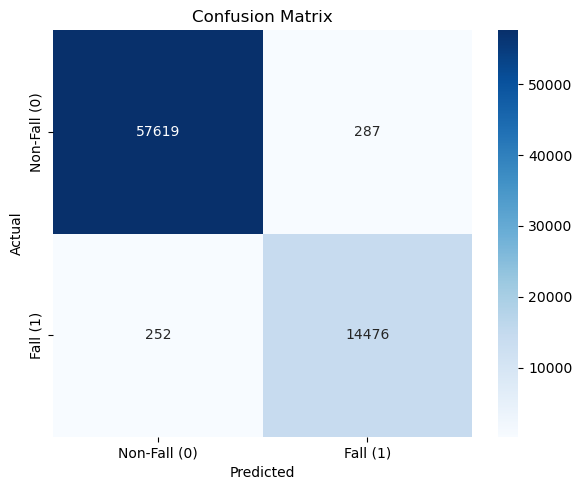


 Random Forest Classification 수식 기반 평가 결과
Accuracy     : 0.9926
Precision    : 0.9806
Recall       : 0.9829
Specificity  : 0.9950
F1 Score     : 0.9817


In [23]:
import os
import json
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

json_dir = "./UPFall"


fall_labels = {1, 2, 3, 4, 5, 11}
non_fall_labels = {6, 7, 8, 9, 10}

X_all = []
y_all = []
for root, _, files in os.walk(json_dir):
    for file in files:
        if file.endswith(".json"):
            file_path = os.path.join(root, file)
            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)
                for item in data:
                    keypoints = item.get("keypoints", [])
                    label = item.get("label", None)
                    if not keypoints or label is None:
                        continue

                    # 신뢰도(3번째 값) 제거
                    keypoints_clean = [val for i, val in enumerate(keypoints) if (i % 3 != 2)]

                    # 라벨 이진 변환
                    if label in fall_labels:
                        binary_label = 1
                    elif label in non_fall_labels:
                        binary_label = 0
                    else:
                        continue  # 라벨이 정의된 범위에 없으면 skip

                    X_all.append(keypoints_clean)
                    y_all.append(binary_label)

#  배열로 변환
X = np.array(X_all)
y = np.array(y_all)

# 데이터 분할 (학습:테스트 = 7:3)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)



rf_model = RandomForestClassifier(
    n_estimators=10,            # 결정 트리 수
    min_samples_split=2,        # 노드를 분할하기 위한 최소 샘플 수
    min_samples_leaf=1,         # 리프 노드가 되기 위한 최소 샘플 수
    bootstrap=True,             # 부트스트랩 샘플링 사용 여부
    random_state=42             # 재현성을 위한 시드 (선택사항)
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fall (0)', 'Fall (1)'],
            yticklabels=['Non-Fall (0)', 'Fall (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0

# 결과 출력
print("\n Random Forest Classification 수식 기반 평가 결과")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1:.4f}")


 - 1-5 FALL  6-11 NONFALL 로 라벨링한 후 RandomForest 모델 결과

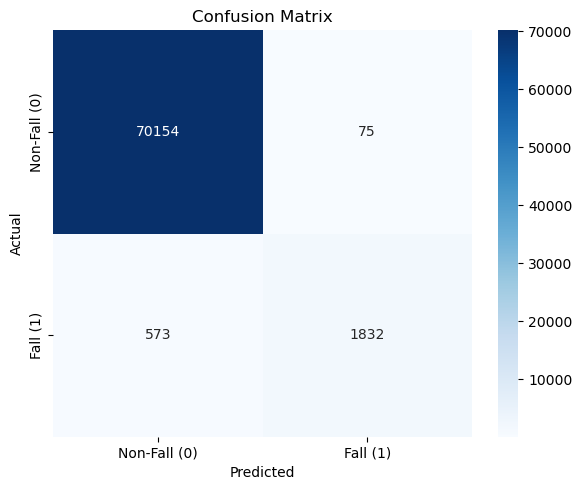


 Random Forest Classification 수식 기반 평가 결과
Accuracy     : 0.9911
Precision    : 0.9607
Recall       : 0.7617
Specificity  : 0.9989
F1 Score     : 0.8497


In [21]:
import os
import json
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

json_dir = "./UPFall"


fall_labels = {1, 2, 3, 4, 5}
non_fall_labels = {6, 7, 8, 9, 10, 11}

X_all = []
y_all = []
for root, _, files in os.walk(json_dir):
    for file in files:
        if file.endswith(".json"):
            file_path = os.path.join(root, file)
            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)
                for item in data:
                    keypoints = item.get("keypoints", [])
                    label = item.get("label", None)
                    if not keypoints or label is None:
                        continue

                    # 신뢰도(3번째 값) 제거
                    keypoints_clean = [val for i, val in enumerate(keypoints) if (i % 3 != 2)]

                    # 라벨 이진 변환
                    if label in fall_labels:
                        binary_label = 1
                    elif label in non_fall_labels:
                        binary_label = 0
                    else:
                        continue  # 라벨이 정의된 범위에 없으면 skip

                    X_all.append(keypoints_clean)
                    y_all.append(binary_label)

#  배열로 변환
X = np.array(X_all)
y = np.array(y_all)

# 데이터 분할 (학습:테스트 = 7:3)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)



rf_model = RandomForestClassifier(
    n_estimators=10,            # 결정 트리 수
    min_samples_split=2,        # 노드를 분할하기 위한 최소 샘플 수
    min_samples_leaf=1,         # 리프 노드가 되기 위한 최소 샘플 수
    bootstrap=True,             # 부트스트랩 샘플링 사용 여부
    random_state=42             # 재현성을 위한 시드 (선택사항)
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fall (0)', 'Fall (1)'],
            yticklabels=['Non-Fall (0)', 'Fall (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0

# 결과 출력
print("\n Random Forest Classification 수식 기반 평가 결과")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1:.4f}")


- 다중분류

              precision    recall  f1-score   support

           1       0.92      0.68      0.78       456
           2       0.91      0.73      0.81       464
           3       0.86      0.65      0.74       470
           4       0.95      0.77      0.85       460
           5       0.88      0.80      0.84       555
           6       1.00      0.98      0.99     13553
           7       0.99      1.00      0.99     19573
           8       1.00      1.00      1.00     16234
           9       0.99      0.92      0.95       572
          10       0.99      1.00      1.00      7974
          11       0.95      1.00      0.97     12323

    accuracy                           0.98     72634
   macro avg       0.95      0.87      0.90     72634
weighted avg       0.98      0.98      0.98     72634



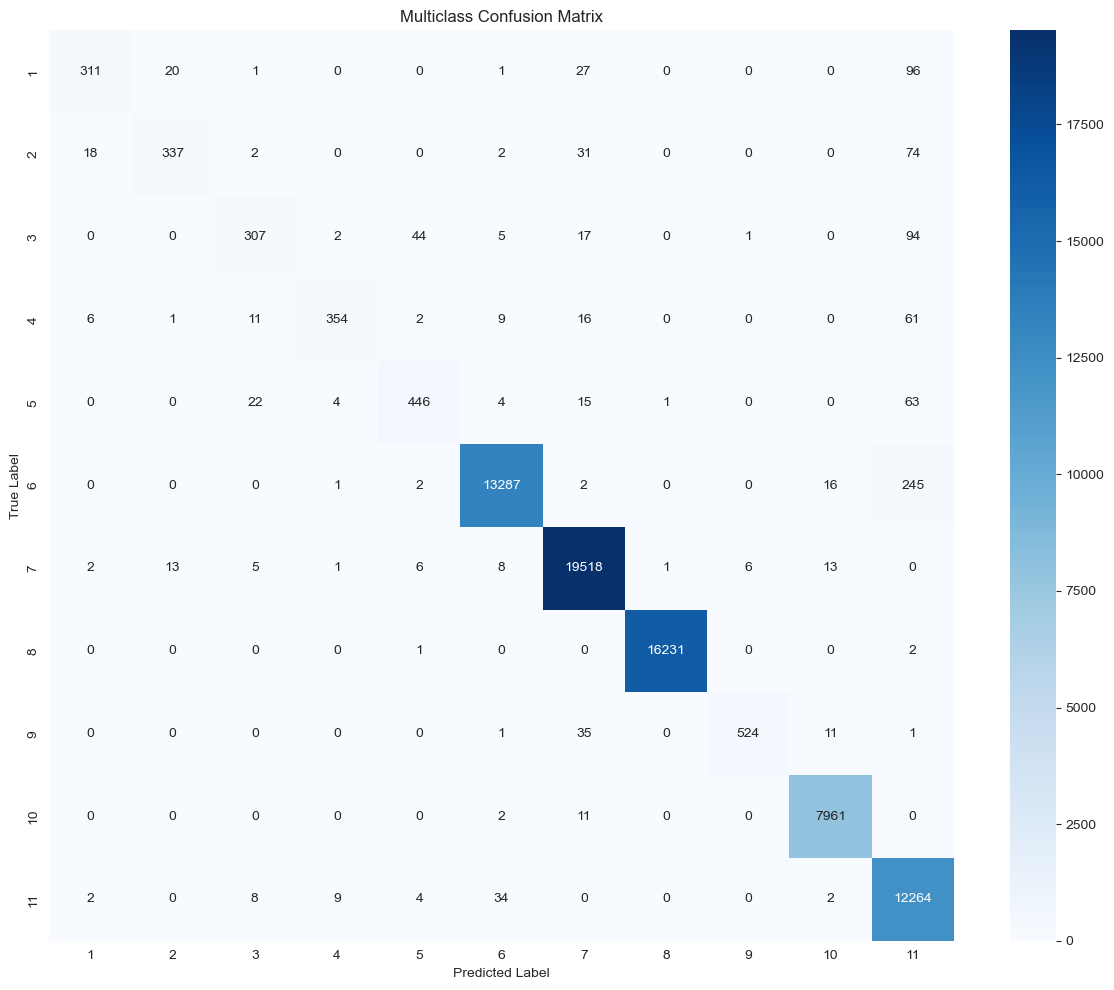

In [38]:
import os
import json
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

json_dir = "./UPFall"

# 라벨 매핑: 1 ~ 11 그대로 사용
label_names = {
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
    10: "10",
    11: "11"
}

X_all = []
y_all = []

for root, _, files in os.walk(json_dir):
    for file in files:
        if file.endswith(".json"):
            file_path = os.path.join(root, file)
            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)
                for item in data:
                    keypoints = item.get("keypoints", [])
                    label = item.get("label", None)
                    if not keypoints or label is None:
                        continue

                    # 신뢰도(score) 제거 → x, y만 남김 (17 keypoints × 2 = 34)
                    keypoints_clean = [val for i, val in enumerate(keypoints) if i % 3 != 2]

                    # 라벨 1~11 범위 확인 후 저장
                    if label in label_names:
                        X_all.append(keypoints_clean)
                        y_all.append(label)

# 배열로 변환
X = np.array(X_all)
y = np.array(y_all)

# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

# 모델 학습
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

# 예측
y_pred = rf_model.predict(X_test)

# 평가
print(classification_report(y_test, y_pred))

# 혼동 행렬
cm = confusion_matrix(y_test, y_pred, labels=sorted(label_names.keys()))

# 라벨 이름 리스트 (정렬된 순서대로)
labels_ordered = [label_names[i] for i in sorted(label_names.keys())]

# 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_ordered,
            yticklabels=labels_ordered)  # y축 거꾸로
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Multiclass Confusion Matrix")
plt.tight_layout()
plt.show()


연습

In [12]:
import os
import json
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

json_dir = "./UPFall"


fall_labels = {1, 2, 3, 4, 5, 11}
non_fall_labels = {6, 7, 8, 9, 10}

X_all = []
y_all = []
for root, _, files in os.walk(json_dir):
    for file in files:
        if file.endswith(".json"):
            file_path = os.path.join(root, file)
            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)
                for item in data:
                    keypoints = item.get("keypoints", [])
                    label = item.get("label", None)
                    if not keypoints or label is None:
                        continue

                    # 신뢰도(3번째 값) 제거
                    keypoints_clean = [val for i, val in enumerate(keypoints) if (i % 3 != 2)]

                    # 라벨 이진 변환
                    if label in fall_labels:
                        binary_label = 1
                    elif label in non_fall_labels:
                        binary_label = 0
                    else:
                        continue  # 라벨이 정의된 범위에 없으면 skip

                    X_all.append(keypoints_clean)
                    y_all.append(binary_label)

In [13]:
y_all

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [14]:
X_all

[[407.2524719238281,
  212.34011840820312,
  413.0387878417969,
  206.55380249023438,
  407.2524719238281,
  206.55380249023438,
  433.2908630371094,
  206.55380249023438,
  424.61138916015625,
  206.55380249023438,
  453.5429382324219,
  249.95111083984375,
  415.93194580078125,
  244.164794921875,
  453.5429382324219,
  307.8141784667969,
  410.1456298828125,
  296.2415466308594,
  430.397705078125,
  359.89093017578125,
  410.1456298828125,
  333.8525390625,
  447.7566223144531,
  345.4251708984375,
  424.61138916015625,
  339.63885498046875,
  433.2908630371094,
  420.64715576171875,
  430.397705078125,
  414.86083984375,
  441.9703063964844,
  475.6170654296875,
  441.9703063964844,
  466.9375915527344],
 [406.8431091308594,
  211.85629272460938,
  409.7388000488281,
  206.06492614746094,
  403.94744873046875,
  206.06492614746094,
  432.904296875,
  208.96060180664062,
  427.1129150390625,
  206.06492614746094,
  453.174072265625,
  249.5001983642578,
  415.5301818847656,
  243.7

In [15]:
#  배열로 변환
X = np.array(X_all)
y = np.array(y_all)


In [16]:

# 데이터 분할 (학습:테스트 = 7:3)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)


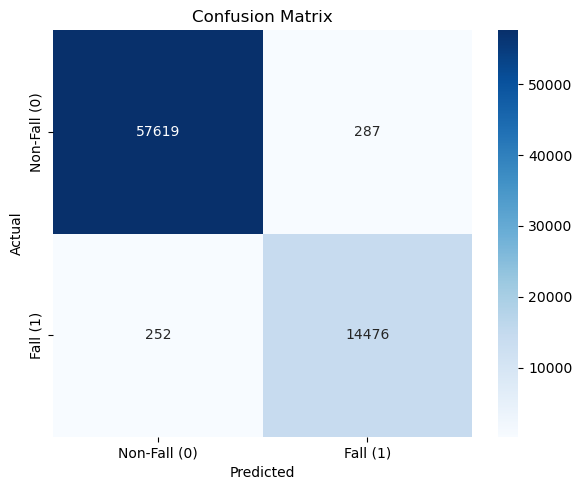


 Random Forest Classification 수식 기반 평가 결과
Accuracy     : 0.9926
Precision    : 0.9806
Recall       : 0.9829
Specificity  : 0.9950
F1 Score     : 0.9817


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

rf_model = RandomForestClassifier(
    n_estimators=10,            # 결정 트리 수
    min_samples_split=2,        # 노드를 분할하기 위한 최소 샘플 수
    min_samples_leaf=1,         # 리프 노드가 되기 위한 최소 샘플 수
    bootstrap=True,             # 부트스트랩 샘플링 사용 여부
    random_state=42             # 재현성을 위한 시드 (선택사항)
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fall (0)', 'Fall (1)'],
            yticklabels=['Non-Fall (0)', 'Fall (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0

# 결과 출력
print("\n Random Forest Classification 수식 기반 평가 결과")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1:.4f}")
